In [55]:
# Viz
import hvplot.xarray
import numpy as np
import odc.stac
import pandas as pd
import planetary_computer
import pyproj
import pystac_client
import xarray as xr
from dask.distributed import Client
from pystac.extensions.eo import EOExtension as eo
from IPython.display import Image
from shapely.geometry import box
import geopandas as gpd


In [56]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

bbox = [19.795435,41.288301,19.888737,41.333453]
datetime = "2024-06-01/2024-09-30"  # Spring months of 2025
collection = "landsat-c2-l2"
platform = "landsat-8"
cloudy_less_than = 5  # percent

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloudy_less_than}, "platform": {"in": [platform]}},
)
items = search.item_collection()
print(f"Returned {len(items)} Items:")
[[i, item.id] for i, item in enumerate(items)]


Returned 6 Items:


[[0, 'LC08_L2SP_186031_20240908_02_T1'],
 [1, 'LC08_L2SP_186031_20240823_02_T1'],
 [2, 'LC08_L2SP_186031_20240807_02_T1'],
 [3, 'LC08_L2SP_186031_20240722_02_T1'],
 [4, 'LC08_L2SP_186031_20240706_02_T1'],
 [5, 'LC08_L2SP_186031_20240620_02_T1']]

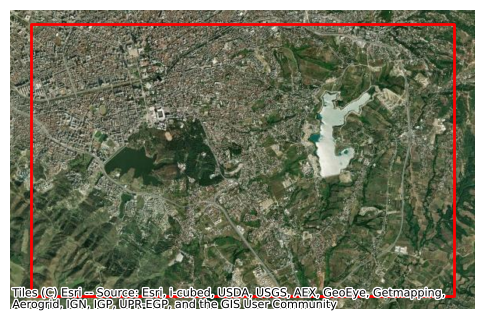

In [57]:
import contextily as cx
import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    geometry=[box(*bbox)],
    crs="EPSG:4326"
)

gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(6, 6))

gdf_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery
)

ax.set_axis_off()
plt.show()



In [58]:
Image(url=items[2].get_assets()['rendered_preview'].href)

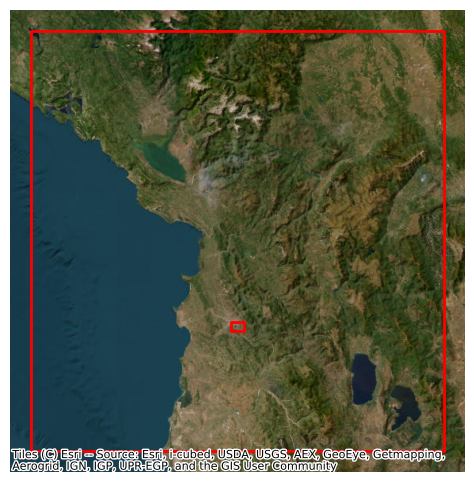

In [59]:

bbox_a = bbox                  # your original bbox
bbox_b = items[2].bbox         # the other one

gdf = gpd.GeoDataFrame(
    {
        "label": ["original", "item_2"],
        "geometry": [
            box(*bbox_a),
            box(*bbox_b),
        ],
    },
    crs="EPSG:4326",
)


gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(6, 6))

gdf_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery
)

ax.set_axis_off()
plt.show()


In [60]:
assets = []
for _, asset in items[2].assets.items():
    try:
        assets.append(asset.extra_fields["eo:bands"][0])
    except:
        pass

cols_ordered = [
    "common_name",
    "description",
    "name",
    "center_wavelength",
    "full_width_half_max",
]
bands = pd.DataFrame.from_dict(assets)[cols_ordered]
bands

,common_name,description,name,center_wavelength,full_width_half_max
0,red,Visible red,OLI_B4,0.65,0.04
1,blue,Visible blue,OLI_B2,0.48,0.06
2,green,Visible green,OLI_B3,0.56,0.06
3,nir08,Near infrared,OLI_B5,0.87,0.03
4,lwir11,Long-wave infrared,TIRS_B10,10.90,0.59
5,swir16,Short-wave infrared,OLI_B6,1.61,0.09
6,swir22,Short-wave infrared,OLI_B7,2.20,0.19
7,coastal,Coastal/Aerosol,OLI_B1,0.44,0.02


In [61]:
tirane_2024 = odc.stac.stac_load(
    [items[2]],
    bands=bands.common_name.values,
    bbox=bbox_a,
    chunks={},  # <-- use Dask
    resolution=30,
).isel(time=0)

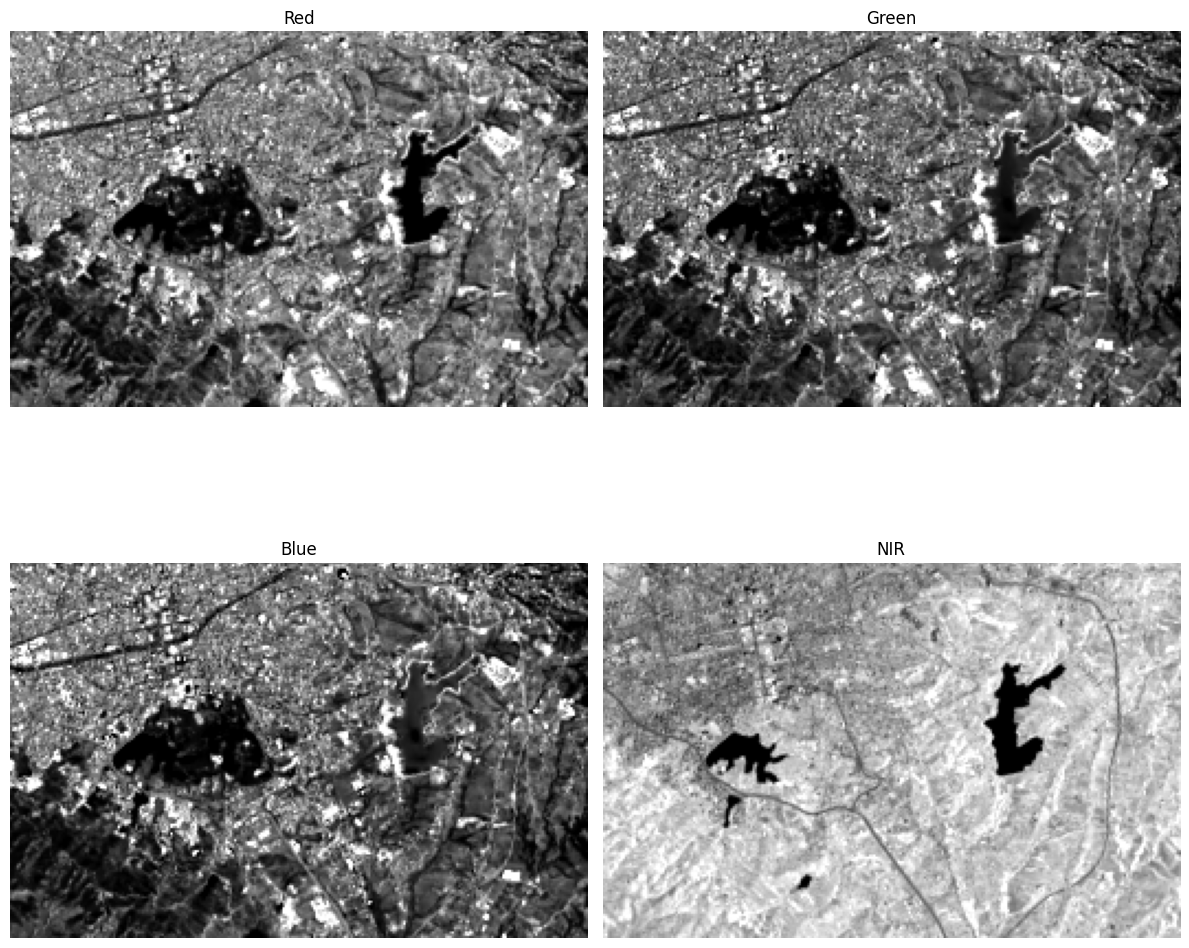

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

bands = ["red", "green", "blue", "nir08"]
band_names = ["Red", "Green", "Blue", "NIR"]

for ax, band, name in zip(axes.flat, bands, band_names):
    data = tirane_2024[band].values

    # Normalize each band
    p2, p98 = np.nanpercentile(data, (2, 98))
    normalized = np.clip((data - p2) / (p98 - p2), 0, 1)

    ax.imshow(normalized, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [63]:
tirane_2024

<xarray.Dataset> Size: 723kB
Dimensions:      (y: 171, x: 263)
Coordinates:
  * y            (y) float64 1kB 4.576e+06 4.576e+06 ... 4.571e+06 4.571e+06
  * x            (x) float64 2kB 3.992e+05 3.992e+05 ... 4.07e+05 4.07e+05
    spatial_ref  int32 4B 32634
    time         datetime64[ns] 8B 2024-08-07T09:22:00.747712
Data variables:
    red          (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    blue         (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    green        (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    nir08        (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    lwir11       (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    swir16       (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    swir22       (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>
    coastal      (y, x) uint16 90kB dask.array<chunksize=(171, 263), meta=np.ndarray>

In [64]:
#xarray and catalog item don't have same projection unless specified -- so copy catalog item crs 
#to xarray -- likely a satellite-based projection. 

epsg = items[2].properties["proj:code"]
tirane_2024.attrs["crs"] = f"epsg:{epsg}"

In [65]:
tirane_2024 = tirane_2024.to_array(dim="band")
tirane_2024

<xarray.DataArray (band: 8, y: 171, x: 263)> Size: 720kB
dask.array<stack, shape=(8, 171, 263), dtype=uint16, chunksize=(1, 171, 263), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) object 64B 'red' 'blue' 'green' ... 'swir22' 'coastal'
  * y            (y) float64 1kB 4.576e+06 4.576e+06 ... 4.571e+06 4.571e+06
  * x            (x) float64 2kB 3.992e+05 3.992e+05 ... 4.07e+05 4.07e+05
    spatial_ref  int32 4B 32634
    time         datetime64[ns] 8B 2024-08-07T09:22:00.747712
Attributes:
    crs:      epsg:EPSG:32634

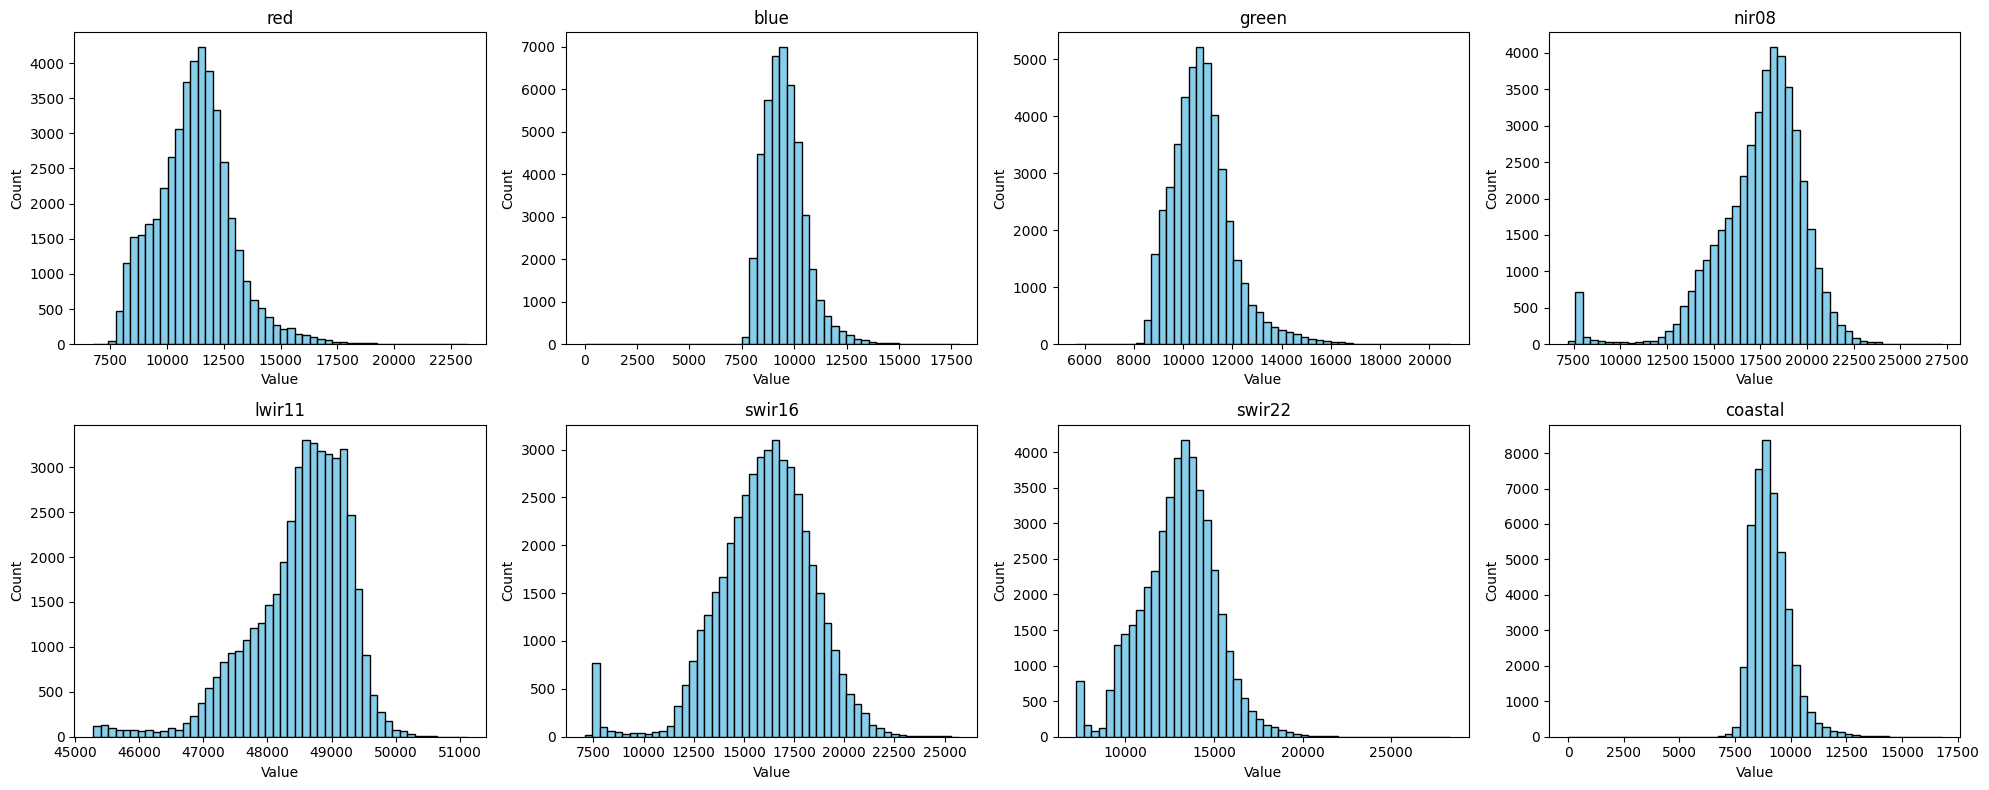

<Figure size 640x480 with 0 Axes>

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# tirane_2024: xarray Dataset with band dimension
# 'data' is the variable holding bands: (band, y, x)
tirane_2024 = tirane_2024.compute()  # now everything is eager

# Get the array
bands = tirane_2024.band.values  # array of band names

n_bands = len(bands)
ncols = 4  # just to arrange nicely
nrows = int(np.ceil(n_bands / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()  # flatten so we can index easily


for i, band in enumerate(bands):
    band_data = tirane_2024.sel(band=band)          # select 2D slice
    flat = band_data.values.flatten()           # flatten to 1D
    flat = flat[~np.isnan(flat)]               # remove NaNs
    axes[i].hist(flat, bins=50, color='skyblue', edgecolor='black')
    axes[i].set_title(band)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

# Remove unused axes
for j in range(n_bands, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


In [50]:
flattened_xda = tirane_2024.stack(z=("x", "y"))  # flatten each band
flattened_t_xda = flattened_xda.transpose("z", "band")
flattened_t_xda

<xarray.DataArray (z: 44973, band: 8)> Size: 720kB
array([[11142,  9448, 10742, ..., 16419, 12918,  8993],
       [10486,  9276, 10357, ..., 15697, 12306,  8927],
       [10881,  9362, 10876, ..., 15920, 12855,  9151],
       ...,
       [ 8733,  8297,  9134, ..., 13813, 10246,  8183],
       [ 9798,  8668,  9678, ..., 15997, 11895,  8447],
       [10622,  9085, 10196, ..., 17182, 12738,  8731]],
      shape=(44973, 8), dtype=uint16)
Coordinates:
  * z            (z) object 360kB MultiIndex
  * band         (band) object 64B 'red' 'blue' 'green' ... 'swir22' 'coastal'
    spatial_ref  int32 4B 32634
    time         datetime64[ns] 8B 2024-08-07T09:22:00.747712
  * x            (z) float64 360kB 3.992e+05 3.992e+05 ... 4.07e+05 4.07e+05
  * y            (z) float64 360kB 4.576e+06 4.576e+06 ... 4.571e+06 4.571e+06
Attributes:
    crs:      epsg:EPSG:32634